In [24]:
!pwd

/home/work/activity_classifier


In [25]:
# for if starting jupyter for the first time / new docker instance
!hdfs dfs -copyFromLocal raw/watch/accel/ hdfs:///watch_accel
!hdfs dfs -copyFromLocal raw/watch/gyro/ hdfs:///watch_gyro
!hdfs dfs -copyFromLocal raw/phone/accel/ hdfs:///phone_accel
!hdfs dfs -copyFromLocal raw/phone/gyro/ hdfs:///phone_gyro

^C
^C
^C
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
copyFromLocal: Filesystem closed
c

In [28]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conf = pyspark.SparkConf().setAll([
    ('spark.master', 'local[6]'),  # use all 6 cores
    ('spark.app.name', 'Basic Setup'),
    ('spark.driver.memory', '6g'),  # leave some RAM for the OS
    ('spark.executor.memory', '6g'),
    ('spark.sql.shuffle.partitions', '12')  # 2x cores
])

spark = SparkSession.builder.config(conf=conf).getOrCreate()

In [29]:
schema = StructType([
    StructField("subject_id", IntegerType(), True),
    StructField("activity_label", StringType(), True),
    StructField("timestamp", LongType(), True),
    StructField("x", FloatType(), True),
    StructField("y", FloatType(), True),
    StructField("z", StringType(), True),
])

In [30]:
watch_accelDF = spark.read.csv("hdfs:///watch_accel/*.txt", schema=schema)
watch_gyroDF = spark.read.csv("hdfs:///watch_gyro/*.txt", schema=schema)
phone_accelDF = spark.read.csv("hdfs:///phone_accel/*.txt", schema=schema)
phone_gyroDF = spark.read.csv("hdfs:///phone_gyro/*.txt", schema=schema)

In [31]:
watch_accelDF = watch_accelDF.withColumn("z", regexp_replace(col("z").cast("string"), ";", "").cast("float"))
watch_gyroDF = watch_gyroDF.withColumn("z", regexp_replace(col("z").cast("string"), ";", "").cast("float"))
phone_accelDF = phone_accelDF.withColumn("z", regexp_replace(col("z").cast("string"), ";", "").cast("float"))
phone_gyroDF = phone_gyroDF.withColumn("z", regexp_replace(col("z").cast("string"), ";", "").cast("float"))

In [32]:
watch_accelDF = watch_accelDF.withColumn("timestamp", (round(col("timestamp") / 50) * 50).cast("long"))
watch_gyroDF = watch_gyroDF.withColumn("timestamp", (round(col("timestamp") / 50) * 50).cast("long"))
phone_accelDF = phone_accelDF.withColumn("timestamp", (round(col("timestamp") / 50) * 50).cast("long"))
phone_gyroDF = phone_gyroDF.withColumn("timestamp", (round(col("timestamp") / 50) * 50).cast("long"))

In [33]:
watch_accelDF.show(5)

[Stage 4:>                                                          (0 + 1) / 1]

+----------+--------------+----------------+----------+----------+----------+
|subject_id|activity_label|       timestamp|         x|         y|         z|
+----------+--------------+----------------+----------+----------+----------+
|      1638|             A|1138138097322000|  7.302415|-5.4199295|  4.485872|
|      1638|             A|1138138117418000| 6.5407987|-3.3218923|0.71371585|
|      1638|             A|1138138137546000| 3.2644117|-2.7231374|0.22513184|
|      1638|             A|1138138157791000| 1.0705738| -3.319497| 1.3771362|
|      1638|             A|1138138177887000|-1.6214283|-3.8272414| 1.0035132|
+----------+--------------+----------------+----------+----------+----------+
only showing top 5 rows


In [34]:
print(watch_accelDF.count())
print(watch_gyroDF.count())

3777046


[Stage 8:===================>                                       (2 + 4) / 6]

3440342


In [35]:
watch_accel = watch_accelDF.select(
    "subject_id", "activity_label", "timestamp",
    col("x").alias("wa_x"), col("y").alias("wa_y"), col("z").alias("wa_z")
)
watch_gyro = watch_gyroDF.select(
    "subject_id", "timestamp",
    col("x").alias("wg_x"), col("y").alias("wg_y"), col("z").alias("wg_z")
)
phone_accel = phone_accelDF.select(
    "subject_id", "activity_label", "timestamp",
    col("x").alias("pa_x"), col("y").alias("pa_y"), col("z").alias("pa_z")
)
phone_gyro = phone_gyroDF.select(
    "subject_id", "timestamp",
    col("x").alias("pg_x"), col("y").alias("pg_y"), col("z").alias("pg_z")
)

watch = watch_accel \
    .join(watch_gyro, on=["subject_id", "timestamp"], how="inner") \
    .drop("timestamp")

phone = phone_accel \
    .join(phone_gyro, on=["subject_id", "timestamp"], how="inner") \
    .drop("timestamp")

In [11]:
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")

In [12]:
watch.cache()
watch.count()

3370861

In [13]:
phone.cache()
phone.count()

2909149

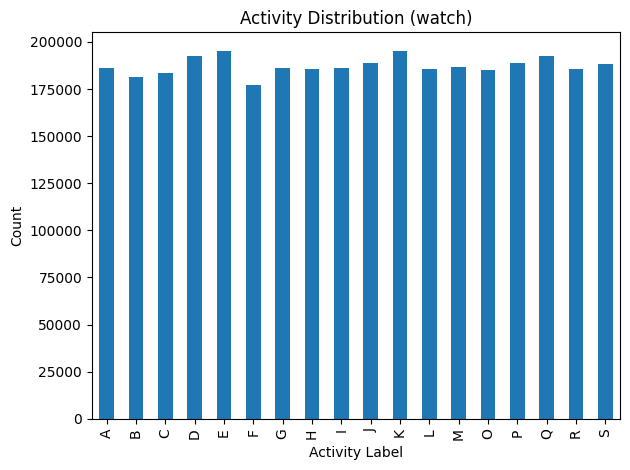

In [14]:
activity_counts = watch.groupBy("activity_label").count().orderBy("activity_label").toPandas()

activity_counts.plot.bar(x="activity_label", y="count", legend=False)
plt.xlabel("Activity Label")
plt.ylabel("Count")
plt.title("Activity Distribution (watch)")
plt.tight_layout()
plt.show()

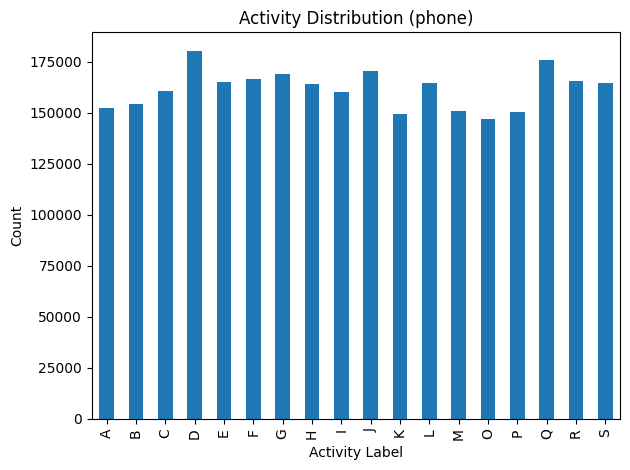

In [15]:
activity_counts = phone.groupBy("activity_label").count().orderBy("activity_label").toPandas()

activity_counts.plot.bar(x="activity_label", y="count", legend=False)
plt.xlabel("Activity Label")
plt.ylabel("Count")
plt.title("Activity Distribution (phone)")
plt.tight_layout()
plt.show()

In [16]:
watch.describe().show()

[Stage 69:==========================================>              (9 + 3) / 12]

+-------+------------------+--------------+------------------+------------------+-----------------+--------------------+--------------------+--------------------+
|summary|        subject_id|activity_label|              wa_x|              wa_y|             wa_z|                wg_x|                wg_y|                wg_z|
+-------+------------------+--------------+------------------+------------------+-----------------+--------------------+--------------------+--------------------+
|  count|           3370861|       3370861|           3370861|           3370861|          3370861|             3370861|             3370861|             3370861|
|   mean|1624.5551115872177|          NULL|0.6450486892824862|-4.349961355877517|2.035766106511265|-0.02930495118387852|-0.03083524215009318|0.015618102089673128|
| stddev|14.369829379564502|          NULL| 7.032424253831541| 5.287769607128633|5.157213770975055|  1.5938755084552003|  1.5102489174358606|  1.4552375891136902|
|    min|             

In [17]:
phone.describe().show()

[Stage 76:==========================================>              (9 + 3) / 12]

+-------+------------------+--------------+------------------+-------------------+------------------+--------------------+--------------------+--------------------+
|summary|        subject_id|activity_label|              pa_x|               pa_y|              pa_z|                pg_x|                pg_y|                pg_z|
+-------+------------------+--------------+------------------+-------------------+------------------+--------------------+--------------------+--------------------+
|  count|           2909149|       2909149|           2909149|            2909149|           2909149|             2909149|             2909149|             2909149|
|   mean|1623.2821598343708|          NULL|0.2829899399615357|-1.0925415616566079|0.6271374368887026|-0.00600368405656...|-0.00607617291654...|-9.81161727738329...|
| stddev|14.290478374885096|          NULL| 5.636289239243066|  6.855367867866462| 5.245143762257804|  0.8307873138689785|    0.93365403751518|  0.6563823816679661|
|    min| 

In [18]:
watchpd = watch.sample(fraction=0.1, seed=42).toPandas()
phonepd = phone.sample(fraction=0.1, seed=42).toPandas()

print(watchpd.shape)
print(phonepd.shape)

(336743, 8)
(290490, 8)


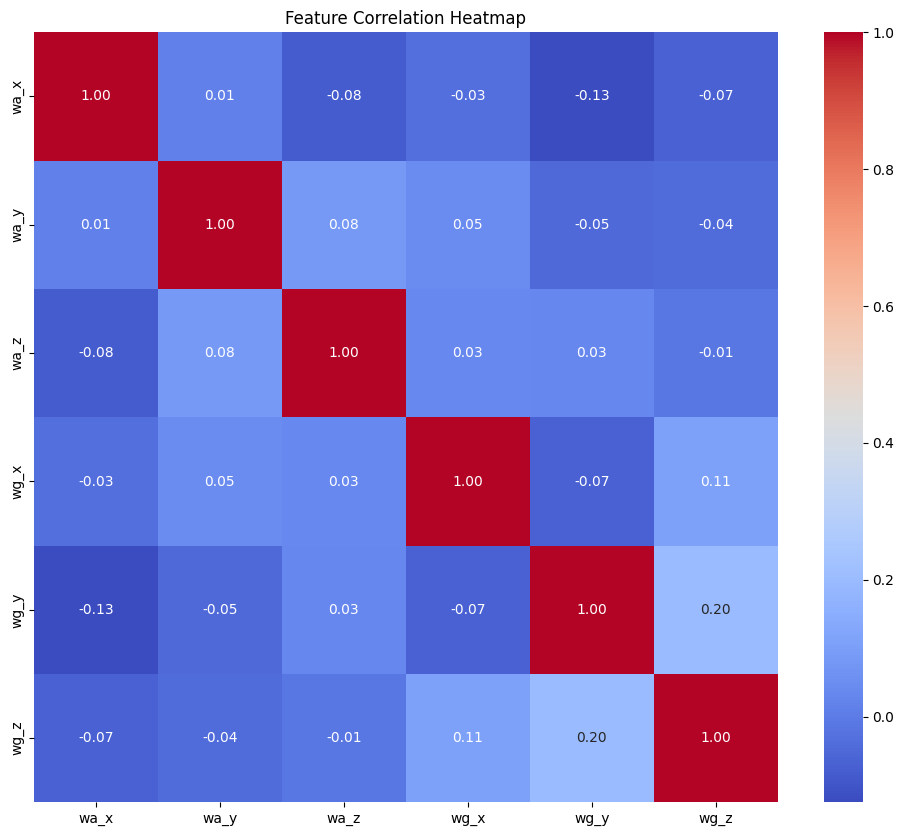

In [19]:
corr = watchpd.drop(columns=["subject_id", "activity_label"]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

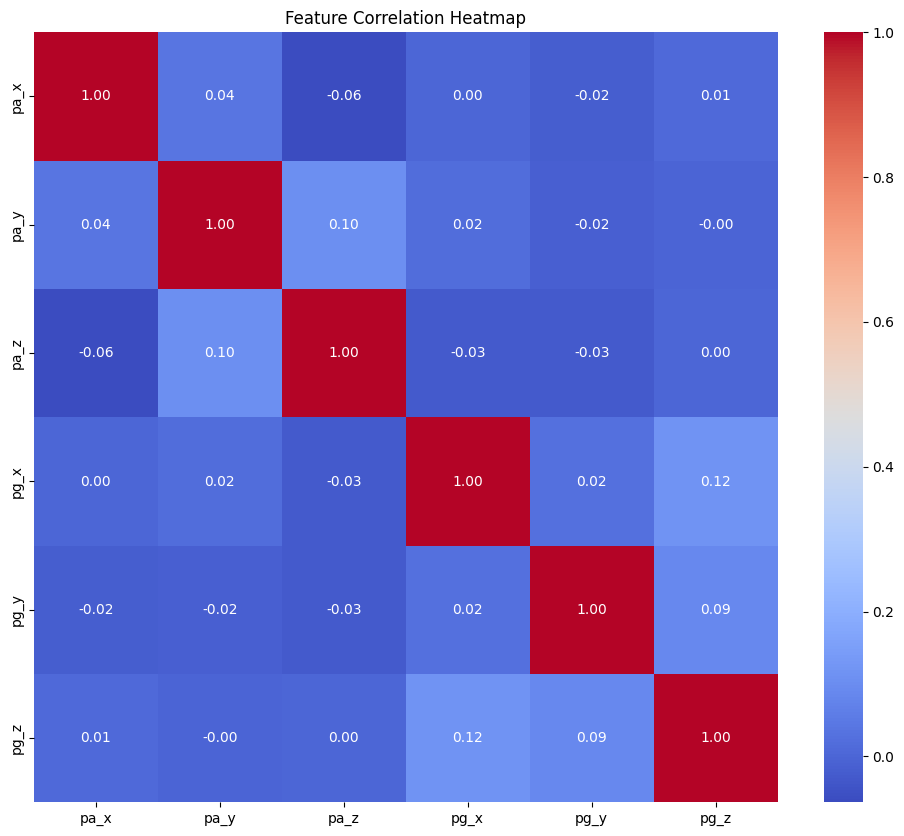

In [20]:
corr = phonepd.drop(columns=["subject_id", "activity_label"]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

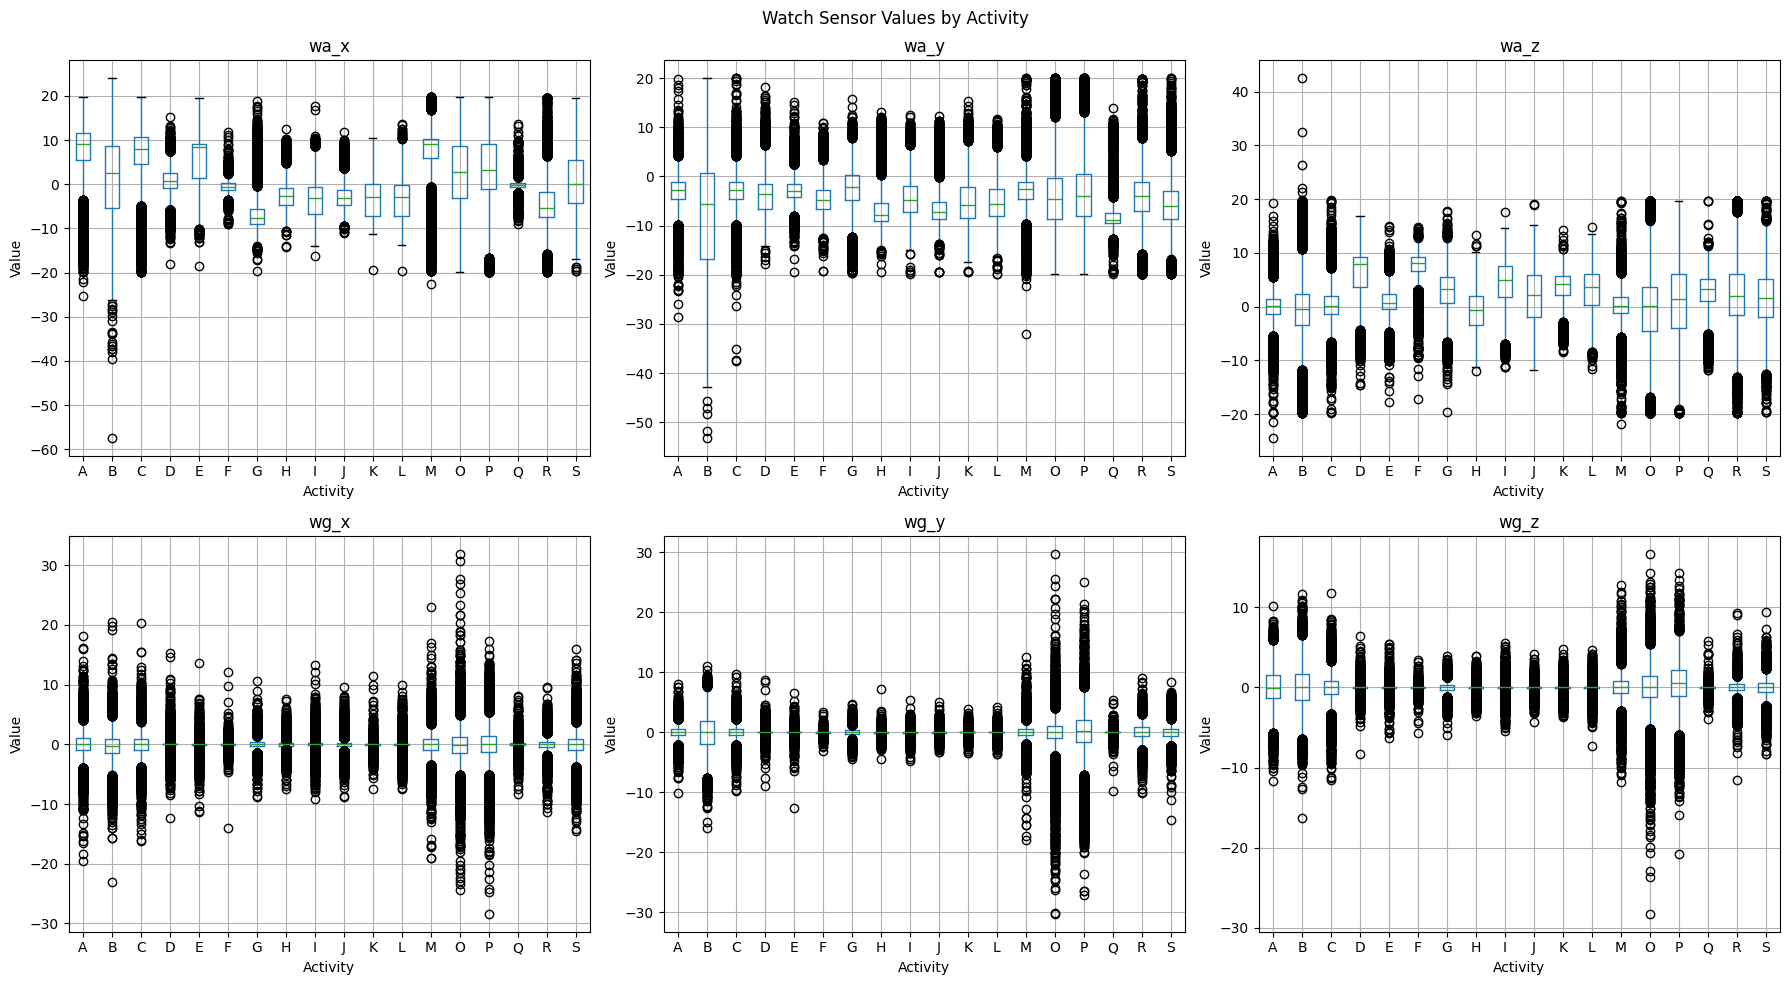

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, c in zip(axes.flatten(), ["wa_x", "wa_y", "wa_z", "wg_x", "wg_y", "wg_z"]):
    watchpd.boxplot(column=c, by="activity_label", ax=ax)
    ax.set_title(c)
    ax.set_xlabel("Activity")
    ax.set_ylabel("Value")

plt.suptitle("Watch Sensor Values by Activity")
plt.tight_layout()
plt.show()

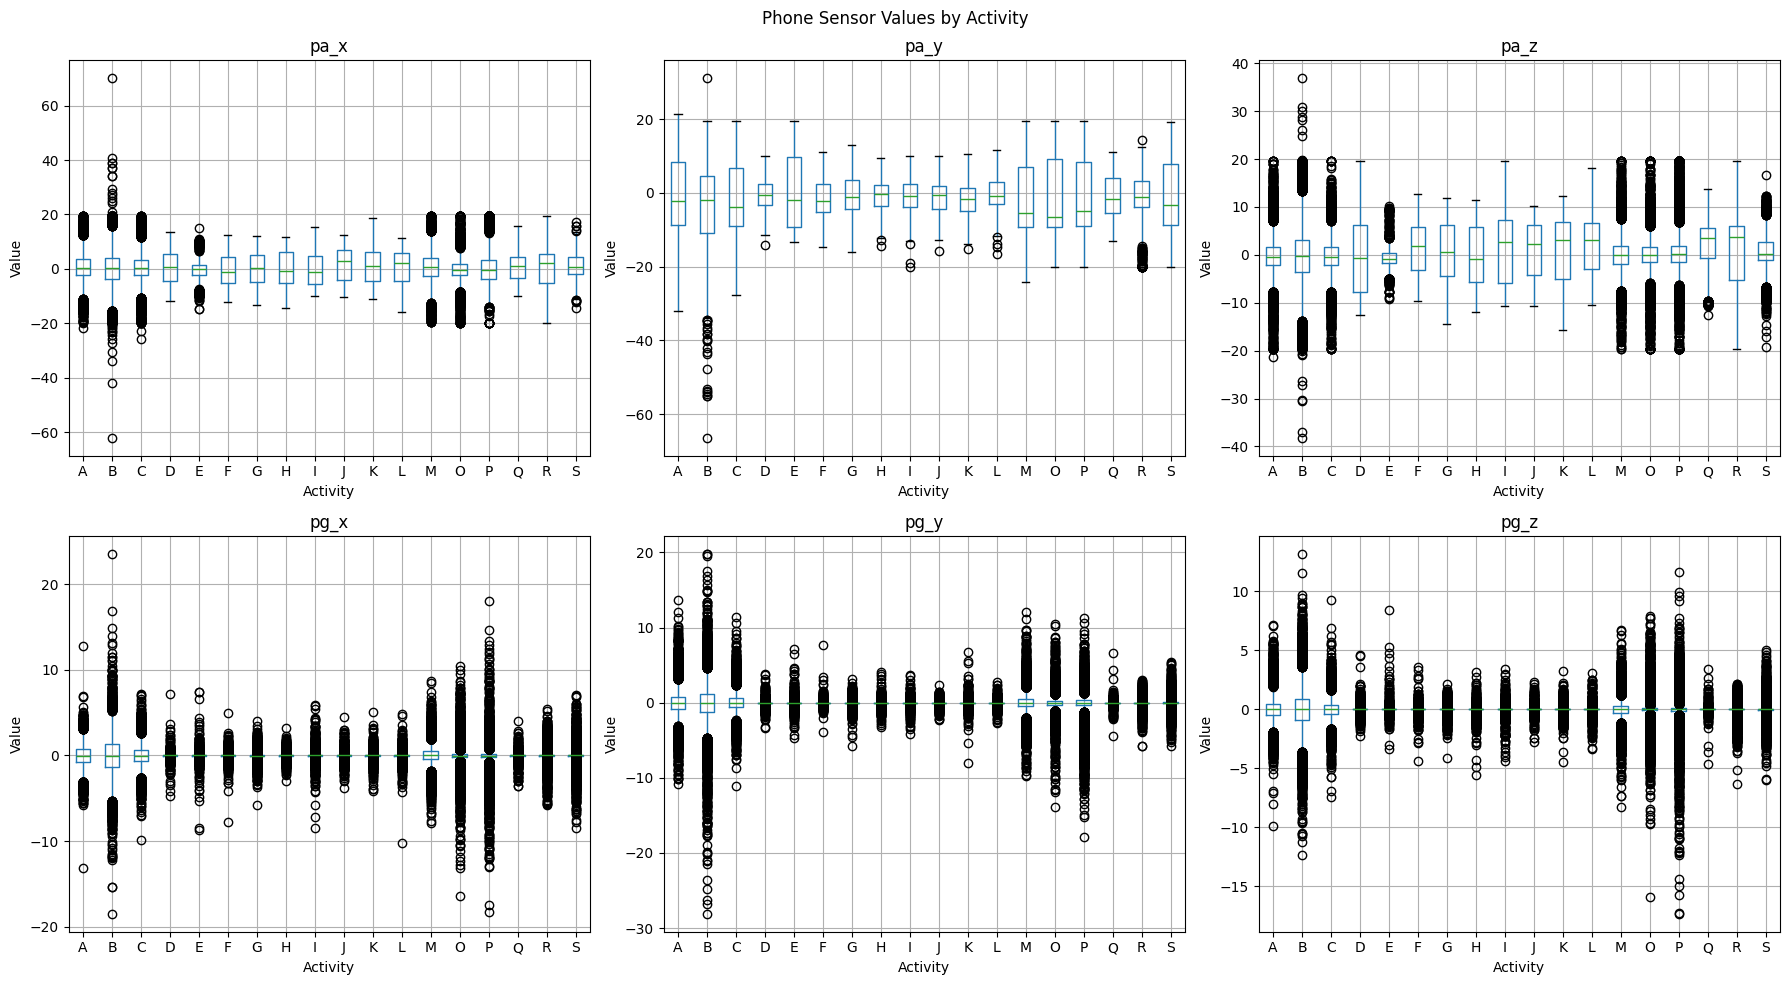

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, c in zip(axes.flatten(), ["pa_x", "pa_y", "pa_z", "pg_x", "pg_y", "pg_z"]):
    phonepd.boxplot(column=c, by="activity_label", ax=ax)
    ax.set_title(c)
    ax.set_xlabel("Activity")
    ax.set_ylabel("Value")

plt.suptitle("Phone Sensor Values by Activity")
plt.tight_layout()
plt.show()

In [36]:
spark.stop()